<a href="https://colab.research.google.com/github/aidazylfo/DAT1-Workshop-Dreamhome/blob/main/mini_llm_workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MiniLLM Workshop

## Build a tiny language model from scratch in pure NumPy

Welcome! Over the next 60–75 minutes you are going to *build* a very small
language model. By the end, you will have typed out the code for every
moving part yourself — no PyTorch, no TensorFlow, just NumPy and
matplotlib.

### 🧑‍💻 What to expect

- 📘 **Explanations in plain English first**, jargon second.
- ▶️ **Demo cells** — read, run, and watch.
- ✏️ **YOUR TURN** cells — small coding exercises with a skeleton and `TODO`s.
- ✅ **Check cells** — they tell you whether your answer works.
- 💡 **Reference cells** — commented-out solutions. Uncomment only if stuck.
- ⏭️ **Optional** — bonus sections you can skip.

If you ever get completely stuck, the file `mini_llm_workshop_solutions.ipynb`
has every exercise pre-filled.

### What you will have built by the end

A model that, when you type `hello`, answers `hello hi there friend`.
It will only know 17 short sentences in total, but you will be able to
point at every number inside it and say *exactly* what it does — and
on some prompts it will even give you a different answer every time
you ask.


### ▶️ Demo: imports and random seed

**What this cell does.** Imports the only two libraries we need for
the whole workshop — NumPy (for all the maths) and matplotlib (for
all the plots). Then it creates a random number generator with a
fixed seed so everyone in the room sees *the same* random numbers
when the model is initialised.

**Why we're running it.** Partly to sanity-check that your Python
environment can import these libraries, and partly to set up `rng`
— we'll use it every time we need a random number later.

**Watch for:** a single line printing the NumPy version. If this
crashes with `ModuleNotFoundError`, run `pip install -r
requirements.txt` in your terminal and try again.


In [ ]:
# The only two libraries we need.
import numpy as np
import matplotlib.pyplot as plt

# Lock in the random seed so everyone sees the same numbers.
rng = np.random.default_rng(seed=42)
print("NumPy version:", np.__version__)


### The whole model on one page

Here is every moving part you are going to build. Do not worry if none of
this makes sense yet — we will build it up one piece at a time.

```
       previous 2 words (the context)
                │
                ▼
       embedding lookup  (E: vocab_size × 8)
                │
                ▼  (concatenate into one vector of length 16)
                x
                │
                ▼
       hidden layer: tanh(W1 · x + b1)    (W1: 24 × 16)
                │
                ▼
       output scores: W2 · h + b2         (W2: vocab_size × 24)
                │
                ▼  (softmax)
       probability of every word
                │
                ▼  (pick the most likely)
       next word!
```

Count the parts: **5 boxes of numbers** called `E`, `W1`, `b1`, `W2`, `b2`.
Together they hold about 2,800 numbers. That is the entire model —
everything else is code that reads those numbers and does arithmetic
with them.

### What are those letters? (the naming convention)

You'll see these same short letter names in almost every ML paper and
tutorial, so it's worth learning them once:

| Name  | Stands for      | What it holds                                             |
|-------|-----------------|-----------------------------------------------------------|
| `E`   | **E**mbedding   | A big table of word vectors. One row per word.            |
| `W1`  | **W**eights 1   | The hidden layer's mixing matrix.                         |
| `b1`  | **b**ias 1      | The hidden layer's baseline offsets (one per output).     |
| `W2`  | **W**eights 2   | The output layer's mixing matrix.                         |
| `b2`  | **b**ias 2      | The output layer's baseline offsets.                      |

The **`1`** and **`2`** are just the layer numbers. `W1` is the first
layer's weights, `W2` is the second layer's weights. Nothing fancy.

These names are a convention, not a law — you could call them
`cat, dog, sofa` and everything would work the same. But since the
whole ML world uses `E, W, b`, we use them too, and now you'll be able
to read any ML paper without being confused.

Don't worry if "weights" and "bias" don't mean anything yet — we'll
build each one up in the next few sections. For now just know that
these five letters are the *only* things the model learns.


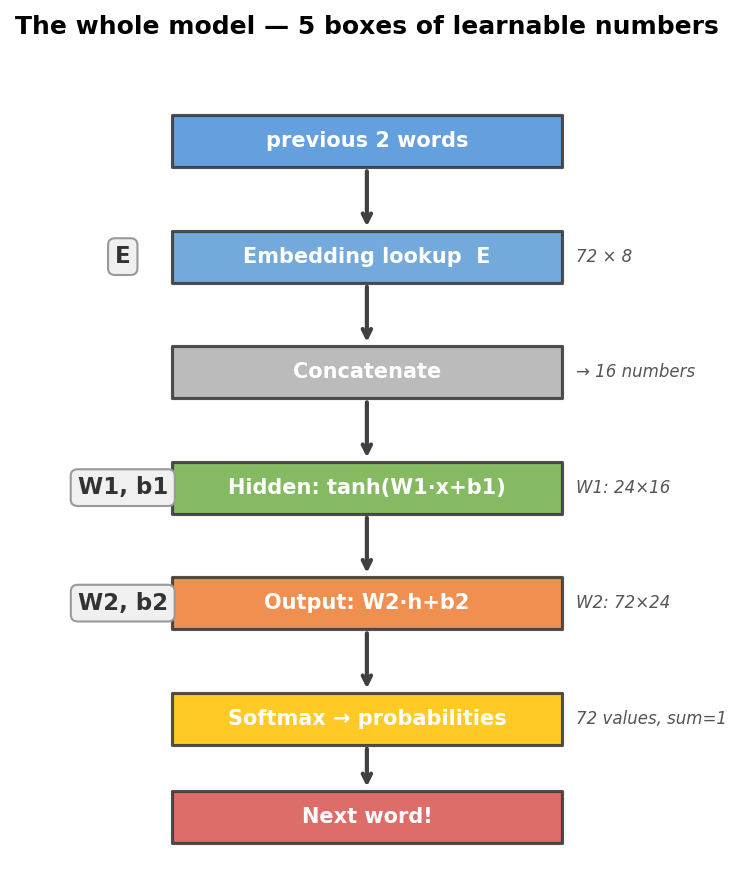


---
## § 1 — Tokens: words become numbers

### 📘 In plain English

Computers only do maths on numbers. Before a computer can process the word
`"cat"`, we have to give it a number. We are going to build a tiny
dictionary that maps every word we care about to a unique integer.

Think of it like assigning roll numbers in a classroom. Once every student
(word) has a number, the teacher (the model) can call on them by number
instead of having to spell out their full name every time.

### Our tiny world

Below is the entire list of sentences our model will ever know about.
These 17 sentences are our **training data**. The model will learn
patterns in them, and nothing else.

The corpus is split into two groups:

- **8 "canonical" sentences** — each has a single valid continuation,
  so the model can learn them deterministically. These are what the
  "it works!" demo at the end of § 11 will show off.
- **9 "branching" sentences** — these deliberately share a starting
  word (`hi`, `goodbye`, `hey`, or `can you`) with *other* sentences
  in the group, so the model learns that those prompts have *multiple*
  valid next words. § 11.5 uses these to show that the model learned
  a whole *distribution* over possible replies, not just one answer.


### ▶️ Demo: print the training corpus

**What this cell does.** Defines a Python list called `CORPUS` with
all 17 sentences in it, then prints each one on its own line.

**Why we're running it.** So you can see the entire universe of text
the model will ever be trained on, at a glance. Everything it "knows"
has to come from these 17 strings.

**Watch for:**
- The **first 8** are the canonical sentences — covering greetings
  (`hello`), animals (`cat`, `dog`), celestial (`sun`, `moon`), and
  programming (`python`, `code`). Each one is a unique fact the model
  will memorise.
- The **last 9** are the branching sentences — three alternative
  responses after `hi`, two after `goodbye`, two after `hey`, and two
  after `can you`. After training, the model will know that these
  prompts each have multiple valid completions.


In [ ]:
# Our tiny training corpus.
#
# The first 8 sentences are the "canonical" ones: each has a single
# deterministic path when we decode greedily. These give us the
# "look, it works!" demo at the end of § 11.
#
# The other 9 sentences are "branching" sentences. They deliberately
# share prefixes ('hi', 'goodbye', 'hey', 'can you') so that after
# training, each of those prompts has MULTIPLE valid continuations.
# We'll come back to this in § 11.5 to show that the model really
# learned a distribution, not a single answer.
CORPUS = [
    # 8 "canonical" sentences — single valid continuation each.
    "hello hi there friend",
    "the cat is happy on the soft bed",
    "a dog barks at the tall tree",
    "what is the sun it lights up our sky",
    "the moon shines down during dark nights",
    "i love writing python code every day",
    "python makes programming simple and fun",
    "code runs fast on any computer",
    # Branch 1: 'hi' leads to 3 different responses
    "hi nice to meet you",
    "hi how are you today",
    "hi welcome home friend",
    # Branch 2: 'goodbye' leads to 2 different responses
    "goodbye see you later",
    "goodbye take care friend",
    # Branch 3: 'hey' leads to 2 different responses
    "hey there i am here",
    "hey friend good day today",
    # Branch 4: 'can you' leads to 2 different requests
    "can you help me please",
    "can you tell me a story",
]

for s in CORPUS:
    print(s)


### ▶️ Demo: build `word_to_idx` and `idx_to_word`

**What this cell does.** Loops through every sentence in the corpus,
collects each unique word into a set, adds the `<START>` and `<END>`
markers at the front, and then builds two lookup dictionaries so we
can convert between words and integer ids in either direction.

**Watch for:**
- `Total vocabulary size: 72` (or similar — it depends on the exact
  sentences).
- Printed `word -> id` table with `<START>` at id 0, `<END>` at id 1,
  and every other word sorted alphabetically after that. The exact
  numbers are arbitrary but they're consistent.
- Notice: `word_to_idx` has both a `<START>` entry (so we can encode
  it) and the `START_ID` constant (which stores the same id so we
  can write it directly without a lookup).


In [ ]:
# Build the vocabulary.
#
# Two special markers:
#   <START>  marks the beginning of a sentence. We also reuse it to fill
#            in "missing" context at the very start of generation (when
#            we don't yet have 2 previous words to look at).
#   <END>    marks the end of a sentence. Generation stops when the model
#            predicts this token.
#
# Everything else is just the unique words from our 17 training sentences.
START = "<START>"
END   = "<END>"

unique_words = set()
for sentence in CORPUS:
    for word in sentence.split():
        unique_words.add(word)

vocab = [START, END] + sorted(unique_words)
VOCAB_SIZE = len(vocab)

# Two lookup tables so we can go word <-> id.
word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for i, w in enumerate(vocab)}

START_ID = word_to_idx[START]
END_ID   = word_to_idx[END]

print(f"Total vocabulary size: {VOCAB_SIZE}")
print()
print("word           -> id")
print("-" * 24)
for w in vocab:
    print(f"{w:14s} -> {word_to_idx[w]}")


NameError: name 'CORPUS' is not defined

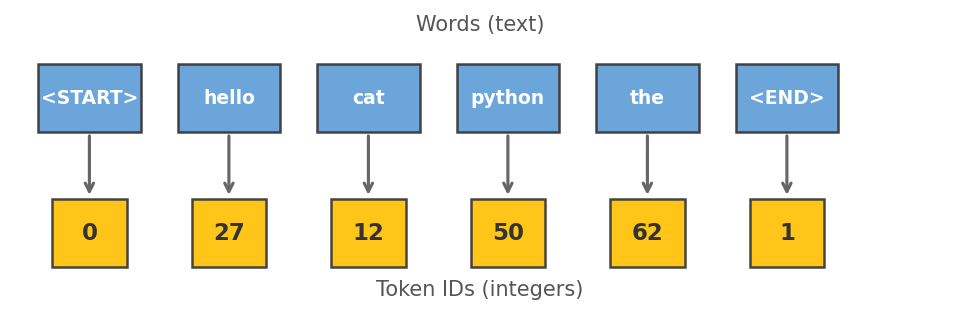


### What did we just do?

We took all 17 sentences, split them into words, collected every unique
word into a set, added two special markers (`<START>` and `<END>`) at
the front, and assigned each one an integer. Now `"cat"` has a number,
so does `"python"`, so does `"hi"`. The exact numbers do not matter —
they are arbitrary labels that will stay consistent for the rest of the
notebook.

**Dictionaries recap:** in Python, `word_to_idx["cat"]` looks up the
integer id for `"cat"`, and `idx_to_word[n]` goes the other way. Regular
Python dictionaries, no NumPy needed.


### ✏️ YOUR TURN #1 — write `encode(text)`

Write a function that turns a sentence like `"the cat"` into a list of ids like `[42, 8]`.

**Steps:**
1. Split the text into words using `.split()`
2. For each word, look up its id in `word_to_idx`
3. Return the list of ids


In [ ]:
def encode(text):
    """Turn a sentence into a list of token ids."""
    ids = []

    # Step 1: split the text into a list of words.
    # Example: "the cat".split() gives ['the', 'cat']
    words = text.split()  # ✅ this line is done for you

    # Step 2: loop over the words and look up each id.
    # Remember: word_to_idx["cat"] gives you cat's integer id.
    for word in words:
        ids.append(  ___  )  # <-- what goes inside the parentheses?

    return ids

# HINT: You can also write this as a one-liner:
#   return [word_to_idx[word] for word in text.split()]


In [ ]:
# ✅ Check: does encode() work?
try:
    assert encode("hello") == [word_to_idx["hello"]]
    assert encode("the cat") == [word_to_idx["the"], word_to_idx["cat"]]
    assert encode("") == []
    print("✅ Your encode function works!")
    print("  encode('hello')   =", encode("hello"))
    print("  encode('the cat') =", encode("the cat"))
except AssertionError:
    print("❌ Not quite — the output doesn't match what we expected.")
except Exception as e:
    print("❌ Your code raised an error:", type(e).__name__, e)


In [ ]:
# 💡 REFERENCE SOLUTION — uncomment and run only if you are stuck.
# (Full solutions: mini_llm_workshop_solutions.ipynb)
#
# def encode(text):
#     """Turn a sentence into a list of token ids."""
#     return [word_to_idx[word] for word in text.split()]


Now the reverse — turning a list of ids back into a readable string.


### ✏️ YOUR TURN #2 — write `decode(ids)`

Write a function that turns a list of ids back into a sentence.

**Steps:**
1. Loop over the ids and look up each word in `idx_to_word`
2. Skip any `<START>` or `<END>` tokens (we don't want to print them)
3. Join the words with single spaces and return the result


In [ ]:
def decode(ids):
    """Turn a list of ids back into a readable sentence."""
    words = []

    for i in ids:
        # Skip the special tokens — we don't want <START>/<END> in the output
        if i not in (START_ID, END_ID):  # ✅ this check is done for you
            words.append(  ___  )  # <-- look up the word for id `i`
                                   #     hint: idx_to_word[i]

    return " ".join(words)

# HINT: You can also write this as a one-liner:
#   words = [idx_to_word[i] for i in ids if i not in (START_ID, END_ID)]


In [ ]:
# ✅ Check: does decode() undo encode()?
try:
    s = "the cat is happy"
    assert decode(encode(s)) == s
    assert decode([START_ID] + encode("hello") + [END_ID]) == "hello"
    print("✅ Your decode function works!")
    print("  round-trip:", decode(encode(s)))
except AssertionError:
    print("❌ Not quite — decode(encode(text)) should give text back.")
except Exception as e:
    print("❌ Your code raised an error:", type(e).__name__, e)


In [ ]:
# 💡 REFERENCE SOLUTION — uncomment and run only if you are stuck.
# (Full solutions: mini_llm_workshop_solutions.ipynb)
#
# def decode(ids):
#     """Turn a list of ids back into a readable sentence."""
#     words = [idx_to_word[i] for i in ids if i not in (START_ID, END_ID)]
#     return " ".join(words)


---
## § 2 — Vectors: lists of numbers

### 📘 In plain English

A **vector** is just a list of numbers. That's it. No scary maths, no
mystery — if you have a shopping receipt `[2.50, 1.99, 4.00]`, that's
a 3-dimensional vector (because it has 3 numbers in it).

We care about vectors because we are going to give every word in our
vocabulary its very own list of 8 numbers. Those 8 numbers will act like
GPS coordinates for the word in an imaginary 8-dimensional space.


### ▶️ Demo: poking at a tiny vector

**What this cell does.** It creates a NumPy array of 3 numbers called
`v` and then prints some basic facts about it: the whole array, its
*shape* (how NumPy describes its size), its length, and individual
elements at specific positions.

**Why we're running it.** To get comfortable with the four things
we'll do with NumPy arrays constantly for the rest of the workshop:
(1) create them, (2) check their shape, (3) check their length, and
(4) grab items by index.

**Watch for:**
- `v.shape` prints as `(3,)` — the trailing comma is NumPy's way of
  saying *"1-dimensional list of 3 numbers"*. You'll see this shape
  notation everywhere from here on.
- `v[0]` gets the first number, `v[-1]` gets the last one — exactly
  like plain Python list indexing.


In [ ]:
# Create a small vector — just a NumPy array of numbers.
v = np.array([2.50, 1.99, 4.00])

print("v        =", v)
print("v.shape  =", v.shape)   # (3,) means "3 numbers in a 1-D list"
print("len(v)   =", len(v))
print("v[0]     =", v[0])       # first number
print("v[-1]    =", v[-1])      # last number


### What does "element-by-element" mean?

When we do maths on a vector, NumPy does it **position by position**.
Line up the two vectors next to each other and operate on each matching
pair — first with first, second with second, and so on.

```
        [ 1,  2,  3]     <- vector a
      + [10, 20, 30]     <- vector b
        -----------
      = [11, 22, 33]     <- the result, same length
```

Position 0 only touches position 0. Position 1 only touches position 1.
The positions never mix with each other. This is sometimes called
*element-wise* or *element-by-element* arithmetic — same thing.

⚠️ **Heads up:** this is NOT what plain Python lists do! In plain
Python, `[1, 2, 3] + [10, 20, 30]` gives you `[1, 2, 3, 10, 20, 30]`
(it glues them together). NumPy adds them. That's one of the big
reasons we use NumPy.


### ▶️ Demo: element-by-element arithmetic in action

**What this cell does.** It creates two vectors `a` and `b` and runs
three different operations on them: addition, multiplying by a single
number (a *scalar*), and multiplying two vectors together.

**Watch for:**
- `a + b` pairs up positions and adds them: `[1+10, 2+20, 3+30]` = `[11, 22, 33]`.
- `a * 2` doubles every single number in `a` in one go.
- `a * b` pairs up positions and multiplies them: `[1*10, 2*20, 3*30]` = `[10, 40, 90]`.
- The result is always the *same length* as the inputs. None of these
  operations mix numbers across positions.


In [ ]:
# Maths on a NumPy vector applies to every position at once.
# Watch each operation — notice how position 0 only affects position 0.
a = np.array([1.0, 2.0, 3.0])
b = np.array([10.0, 20.0, 30.0])

print("a + b =", a + b)       # pairs added:    1+10, 2+20, 3+30
print("a * 2 =", a * 2)        # every number doubled
print("a * b =", a * b)        # pairs multiplied: 1*10, 2*20, 3*30


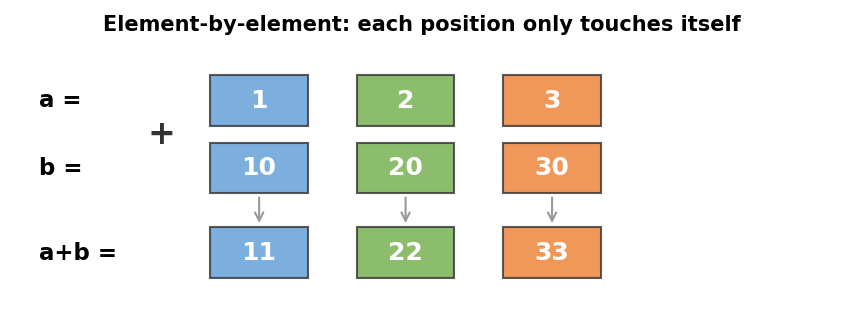


The word for "how many numbers are in a vector" is **dimensionality**.
So `v` above is a 3-dimensional vector. When we start giving words 8
numbers each, those will be 8-dimensional vectors. You cannot picture
8 dimensions — nobody can — and you do not need to. It is just a list
with 8 entries.


### ✏️ YOUR TURN #3 — add two vectors and total the result

Take two vectors, add them together (pair by pair), then add up every number in the result into one single number.

**Steps:**
1. Add `x` and `y` using the `+` operator (NumPy pairs them up automatically)
2. Call `.sum()` on the result to collapse it into one number

This is a tiny warm-up to make sure you are comfortable with NumPy arrays before we hit the big stuff.


In [ ]:
x = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([10.0, 20.0, 30.0, 40.0])

# Step 1: add the two vectors (NumPy does it element-by-element)
summed_vector = ___    # <-- x + y  (should give [11, 22, 33, 44])

# Step 2: collapse into one number
total = ___            # <-- summed_vector.sum()  (should give 110)

print("summed_vector =", summed_vector)
print("total         =", total)


In [ ]:
# ✅ Check
try:
    assert np.allclose(summed_vector, [11.0, 22.0, 33.0, 44.0])
    assert np.isclose(total, 110.0)
    print("✅ Nice. You can add vectors and sum them.")
except (AssertionError, TypeError, AttributeError):
    print("❌ Not quite. summed_vector should be [11,22,33,44] and total should be 110.")


In [ ]:
# 💡 REFERENCE SOLUTION — uncomment and run only if you are stuck.
# (Full solutions: mini_llm_workshop_solutions.ipynb)
#
# x = np.array([1.0, 2.0, 3.0, 4.0])
# y = np.array([10.0, 20.0, 30.0, 40.0])
#
# summed_vector = x + y
# total = summed_vector.sum()
#
# print("summed_vector =", summed_vector)
# print("total         =", total)


---
## § 3 — The embedding table

### 📘 In plain English

Now imagine a spreadsheet. Each row of the spreadsheet is one of our
vocabulary words. Each row has 8 numbers in it. Row 0 belongs to
`<START>`, row 5 belongs to `"cat"`, and so on.

This spreadsheet is called the **embedding table**, written as `E`
(the letter stands for **E**mbedding). Looking up a word's vector is
just "fetch row number N of the spreadsheet" — in Python, that's
`E[n]`.

Right now we are going to fill the spreadsheet with random numbers. They
will be meaningless. Later, training will teach the model what good
numbers to put here.

### Quick NumPy detour: `rng.standard_normal`

`rng.standard_normal(shape)` creates a table of random numbers of any
shape you want. The random numbers are drawn from a *normal distribution*
(the bell curve you probably saw in school) centred on zero, so they
are mostly small, some slightly positive, some slightly negative. We
then multiply by `0.1` to make them even smaller — we want the starting
weights to be tiny nudges, not huge ones.

**What does the output look like?** If you called
`rng.standard_normal((3, 4)) * 0.1`, you'd get something like this:

```
[[ 0.032, -0.082,  0.014,  0.051],
 [-0.016,  0.099, -0.042,  0.077],
 [ 0.003, -0.061,  0.121, -0.008]]
```

Three rows, four columns, all numbers near zero but with some scatter
in both directions. Exactly what we want as a starting point — small,
random, mixed signs.

**For this workshop that's all you need to know:** `rng.standard_normal(shape)`
gives you a table of that shape filled with small-ish random numbers.
The `* 0.1` makes them even smaller so the model starts in a calm,
neutral state.


### ▶️ Demo: create the embedding table `E`

**What this cell does.** Picks the embedding dimension (8), creates
the full embedding table `E` as random numbers, and prints its shape
and the first 3 rows.

**Watch for:**
- `E.shape` will be `(72, 8)` (or however big your vocab is × 8).
- Every row printed is 8 numbers near zero — that's *one word's
  vector*. Each word in our vocabulary has its own row like this.
- The numbers are meaningless right now. Training will replace them
  with values that actually encode word relationships.


In [ ]:
# How many numbers per word. 8 is an arbitrary choice — small enough
# to print, big enough for the model to learn something interesting.
EMBED_DIM = 8

# Create the embedding table:
#   - VOCAB_SIZE rows (one per word in our vocabulary)
#   - EMBED_DIM columns (8 numbers per word)
#   - Start with small random numbers (we'll train them later)
E = rng.standard_normal((VOCAB_SIZE, EMBED_DIM)) * 0.1

print("E.shape =", E.shape)
print(f"That's {VOCAB_SIZE} rows (one per word) × {EMBED_DIM} numbers per row.")
print(f"Total numbers in E: {E.size}")
print()
print("First 3 rows of E (the first 3 words' vectors):")
print(E[:3])


### ▶️ Demo: look up a single word's vector

**What this cell does.** Walks through the two steps of looking up a
word's embedding: (1) find the word's id in `word_to_idx`, (2) fetch
that row number from `E`. That's all "looking up an embedding" is.

**Watch for:**
- `'cat' has id N` — `N` is some integer assigned when we built the
  vocabulary in § 1.
- `E[N] = [...]` prints 8 small numbers — the vector for `'cat'`.
- It really is just row indexing into a table. Nothing fancy.


In [ ]:
# Looking up a word's vector.
# Step 1: find the word's id.
cat_id = word_to_idx["cat"]
print(f"'cat' has id {cat_id}")

# Step 2: fetch that row from E.
cat_vector = E[cat_id]
print(f"E[{cat_id}] = {cat_vector}")
print(f"It's a vector with {len(cat_vector)} numbers in it.")


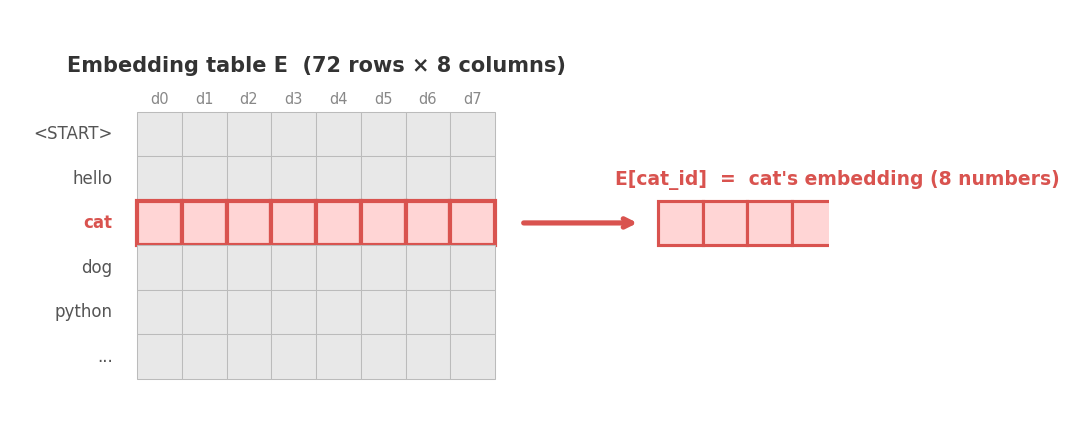


### ▶️ Demo: visualise the whole embedding table as a heatmap

**What this cell does.** Draws the entire `E` matrix as a colour grid.
Each horizontal row is one word; each column is one of the 8
dimensions of the embedding. Red means positive, blue means negative,
white means near zero.

**Why we're running it.** Because later, after training, we'll run this
*exact same cell* again and compare. Right now it's pure noise. Later,
it will have structure — and the difference is the whole point of the
workshop.

**Watch for:**
- A completely random pattern of red and blue. No rhyme or reason.
- The colours are faint (we multiplied by `0.1`) so the contrast is
  mild. That's expected.
- **Take a mental snapshot of this picture.** You'll want to compare
  it to the post-training version in § 10.


In [ ]:
# Visualise the whole embedding table as a heatmap.
# Each row is a word, each column is one of the 8 numbers in its vector.
# Right now it's just noise — but remember what it looks like, because
# we'll see it again after training.
fig, ax = plt.subplots(figsize=(6, max(3, VOCAB_SIZE * 0.2)))
im = ax.imshow(E, cmap="RdBu", aspect="auto", vmin=-0.3, vmax=0.3)
ax.set_yticks(range(VOCAB_SIZE))
ax.set_yticklabels(vocab, fontsize=8)
ax.set_xticks(range(EMBED_DIM))
ax.set_xlabel("embedding dimension (0–7)")
ax.set_title("Embedding table E (random, untrained)")
plt.colorbar(im, ax=ax, label="value")
plt.tight_layout()
plt.show()


### ✏️ YOUR TURN #4 — write `embed(word)`

Wrap the word → id → vector lookup in a single helper so we can use it later.

**Steps:**
1. Look up the word's id in `word_to_idx`
2. Return the matching row of `E`


In [ ]:
def embed(word):
    """Return the embedding vector for a single word."""
    # Two steps, just like the demo above:
    #   step 1: word_to_idx[word]  gives the integer id
    #   step 2: E[that_id]         gives the 8-number vector
    #
    # You can combine them: E[word_to_idx[word]]
    return ___  # <-- one expression that does both steps


In [ ]:
# ✅ Check
try:
    v_cat = embed("cat")
    assert v_cat.shape == (EMBED_DIM,), "should return a length-8 vector"
    assert np.allclose(v_cat, E[word_to_idx["cat"]])
    print("✅ embed('cat') returns the right row.")
    print("  embed('cat') =", v_cat)
except (AssertionError, AttributeError, TypeError):
    print("❌ Not quite — embed('cat') should return E[word_to_idx['cat']].")


In [ ]:
# 💡 REFERENCE SOLUTION — uncomment and run only if you are stuck.
# (Full solutions: mini_llm_workshop_solutions.ipynb)
#
# def embed(word):
#     """Return the embedding vector for a single word."""
#     return E[word_to_idx[word]]


---
## § 4 — Matrices and matrix multiply (ELI5)

### 📘 In plain English

A **matrix** is a spreadsheet of numbers — rows and columns. We already
saw one: the embedding table `E`. That was a matrix the whole time, we
just called it a table.

We need to do one operation with matrices: **matrix multiply**. It sounds
scary. It isn't. We're going to build it up in two tiny steps.

### Step 1: a "dot product" of two vectors

Before we multiply a matrix by a vector, we need to know what happens
when you multiply *two vectors* together to get a single number. This
operation is called a **dot product**, and it's just:

> Multiply matching pairs, then add all the results up.

That's it. Here's what it looks like on paper:

```
     [1, 2, 3]  •  [10, 20, 30]
   = (1·10) + (2·20) + (3·30)
   = 10 + 40 + 90
   = 140
```

A dot product takes two same-length lists and produces **one single
number**. Let's try it in code.


### ▶️ Demo: dot product three different ways

**What this cell does.** Computes the same dot product three different
ways — once by hand using indexing, once with `np.dot`, and once with
the `@` operator. Shows they all give the same answer.

**Why we're running it.** To make it concrete that the scary-sounding
"dot product" is really just *multiply pairs, add them up*, and to
meet NumPy's `@` operator which we'll use for the rest of the
workshop.

**Watch for:**
- All three results should print `140`. Same answer, different syntax.
- `@` is the operator we'll use from now on — shorter to write, and
  (as we'll see next) it generalises to matrices too.


In [ ]:
# Dot product by hand, then with NumPy.
a = np.array([1, 2, 3])
b = np.array([10, 20, 30])

# By hand: multiply pairs, add them up.
by_hand = (a[0]*b[0]) + (a[1]*b[1]) + (a[2]*b[2])
print("by hand:", by_hand)

# NumPy can do it in one call.
print("np.dot:", np.dot(a, b))

# Or using the @ operator.
print("a @ b :", a @ b)


All three give `140`. The `@` operator is NumPy's "multiply" that
knows about matrices and vectors. For two vectors, it does a dot product.
For a matrix and a vector, it does something slightly bigger — which is
the next step.

### Step 2: matrix-vector multiply = many dot products at once

Now imagine you want to do several dot products at the same time, one
for each row of a table. That is exactly what **matrix-vector multiply**
is. Each row of the matrix is one dot product waiting to happen.

So `M @ v` means: "for each row in `M`, take the dot product of that row
with `v`. Stack the answers up into a new vector."

If `M` has 3 rows, the result has 3 numbers. If `M` has 24 rows, the
result has 24 numbers. **The number of rows in the matrix decides the
length of the output vector.**

### The DJ mixing-board analogy (optional mental picture)

Think of `v` as a row of input sliders on a DJ mixer. Each row of `M`
is a recipe saying "for output channel #1, take 30% of slider 1 + 50%
of slider 2 + 20% of slider 3". One row = one output channel. The full
result is every output channel stacked up into a new vector.

Let's do one by hand and then have NumPy check our work.


### ▶️ Demo: matrix-vector multiply by hand, then with NumPy

**What this cell does.** Defines a small 3×2 matrix `M` where each row
has a human-readable "recipe" comment, and a 2-long input vector `v`.
Then it computes the dot product for each row of `M` against `v` one
at a time (so you can see the arithmetic), and finally has NumPy do
the whole thing in one `M @ v` call.

**Why we're running it.** To convince you with real numbers that
`M @ v` is just "one dot product per row of M, stacked up". No magic.

**Watch for:**
- Row 0's recipe is `[1, 0]` — "keep the first input, ignore the
  second". Result should be `10.0` (just `v[0]`).
- Row 1's recipe is `[0.5, 0.5]` — "average the two inputs". Result
  should be `15.0` (the average of 10 and 20).
- Row 2's recipe is `[0, 1]` — "ignore the first, keep the second".
  Result should be `20.0` (just `v[1]`).
- `M @ v` at the bottom gives `[10, 15, 20]` — the same three
  numbers, produced in one line instead of three.


In [ ]:
# A 3-row, 2-column matrix M and a 2-long vector v.
# M has 3 rows → the result will have 3 numbers.
M = np.array([
    [1.0, 0.0],    # row 0: 'keep the first input, ignore the second'
    [0.5, 0.5],    # row 1: 'average of the two inputs'
    [0.0, 1.0],    # row 2: 'ignore the first input, keep the second'
])
v = np.array([10.0, 20.0])

# By hand: one dot product per row of M.
row_0_result = M[0, 0]*v[0] + M[0, 1]*v[1]   # 1*10 + 0*20 = 10
row_1_result = M[1, 0]*v[0] + M[1, 1]*v[1]   # 0.5*10 + 0.5*20 = 15
row_2_result = M[2, 0]*v[0] + M[2, 1]*v[1]   # 0*10 + 1*20 = 20

print("Row 0 dot product:", row_0_result)
print("Row 1 dot product:", row_1_result)
print("Row 2 dot product:", row_2_result)

# NumPy does all three dot products at once.
print()
print("M @ v =", M @ v)


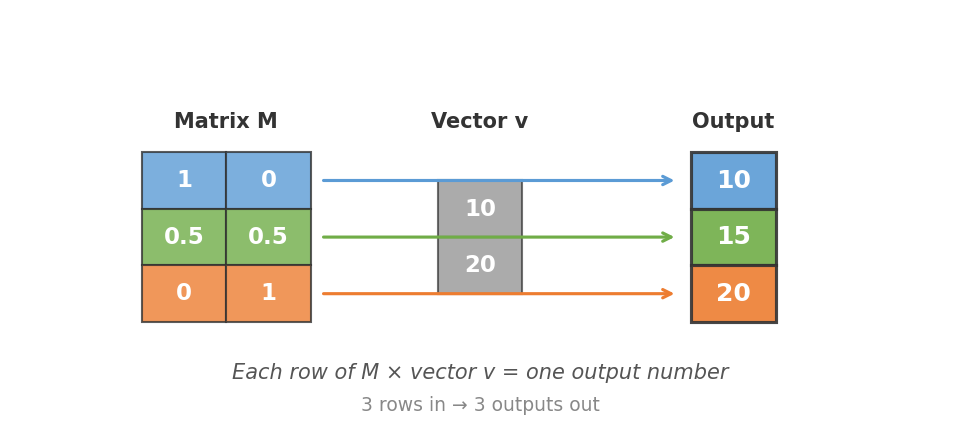


The `@` operator gave us the same three numbers we computed by hand,
just in one step. That's all matrix-vector multiply is — a batch of dot
products, one per row.

**Key insight for our model:** multiplying a vector by a matrix *changes
its size*. The input `x` had 2 numbers. The matrix `M` had 3 rows. So
the output has 3 numbers. We use this to reshape data between layers —
going from 16 numbers (two embeddings stuck together) up to 24 numbers
in the hidden layer, then back down to 72 numbers (one score per word).


### ✏️ YOUR TURN #5 — compute a tiny matrix-vector product

Use NumPy's `@` operator to multiply a matrix by a vector.

No tricks — just one line of code and then confirm the result by eye.


In [ ]:
M2 = np.array([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
])
v2 = np.array([1.0, 0.0, -1.0])

# Use the @ operator, just like the demo above.
# M2 has 2 rows, v2 has 3 entries, so the output will have 2 numbers.
result = ___  # <-- M2 @ v2

print("result =", result)
# Check by hand: row 0 = 1*1 + 2*0 + 3*(-1) = -2
#                row 1 = 4*1 + 5*0 + 6*(-1) = -2


In [ ]:
# ✅ Check
try:
    assert np.allclose(result, [-2.0, -2.0])
    print("✅ Correct — you can multiply matrices by vectors.")
except (AssertionError, TypeError):
    print("❌ Not quite — result should be [-2.0, -2.0].")


In [ ]:
# 💡 REFERENCE SOLUTION — uncomment and run only if you are stuck.
# (Full solutions: mini_llm_workshop_solutions.ipynb)
#
# M2 = np.array([
#     [1.0, 2.0, 3.0],
#     [4.0, 5.0, 6.0],
# ])
# v2 = np.array([1.0, 0.0, -1.0])
#
# result = M2 @ v2
#
# print("result =", result)


---
## § 5 — The hidden layer

### 📘 In plain English

The "hidden layer" sounds mysterious but it is literally just two steps
applied to the input:

1. **Mix**: multiply the input by a matrix `W1` and add a bias vector
   `b1`. This transforms the input numbers into a new set of numbers.
2. **Squish**: run the result through a function called `tanh` that
   squishes every number into the range −1 to +1.

The word "hidden" just means "sits between the input and the output".
There is nothing hidden from you — you can print every number inside
it if you want.

### What are `W1` and `b1`, really?

Remember from the § 0 naming table: `W1` = **weights** of the first
layer, `b1` = **bias** of the first layer.

- **`W1` is a matrix** (a table of numbers). It has shape `(24, 16)`,
  meaning 24 rows × 16 columns. Each row is a "recipe" that mixes the
  16 input numbers together to produce one output number. 24 rows means
  24 output numbers. Those 24 numbers are this matrix's contribution to
  what we call the *hidden state* `h`.
- **`b1` is a vector** of 24 numbers (one per row of `W1`). A **bias**
  is just a baseline offset — a fixed number added to each output
  *regardless* of what the input is. Without a bias, the output is
  always zero when the input is all zeros. The bias lets us shift
  things around.

The formula `W1 @ x + b1` just means: "do the matrix multiply, then add
the bias to each output". That's the whole of step 1.

### Why the squish? (activation function)

If we only multiplied by matrices and never added a non-linear twist,
stacking multiple layers would be pointless — two matrix multiplies
back-to-back are mathematically equivalent to *one bigger* matrix
multiply. So without the `tanh` squish, our "two layer" model would
collapse to a plain one-layer model and couldn't learn anything clever.

**`tanh` bends the line.** It's a function called an *activation
function*. All it does is squish any number into the range −1 to +1.
Big positive in → almost +1 out. Big negative in → almost −1 out.
Zero in → zero out. That tiny bit of bending is what gives stacked
layers their extra learning power.


### ▶️ Demo: create `W1` and `b1`

**What this cell does.** Defines three numbers we'll reuse for the
rest of the workshop:

- **`CONTEXT_SIZE = 2`** — how many previous words the model looks
  at when predicting the next word. You saw this in the § 0 diagram
  ("previous 2 words"). It's first defined here in code.
- **`INPUT_DIM = EMBED_DIM * CONTEXT_SIZE = 8 × 2 = 16`** — the
  hidden layer's input is two 8-number embeddings glued together, so
  16 numbers. `EMBED_DIM` was defined back in § 3 as 8.
- **`HIDDEN_DIM = 24`** — how many output numbers the hidden layer
  produces. Bigger = more capacity, smaller = faster. 24 is a
  comfortable middle.

Then it creates the hidden layer's weight matrix `W1` (random) and
bias `b1` (all zeros).

**Watch for:**
- `W1.shape = (24, 16)` — 24 output numbers, each mixed from 16 inputs.
- `b1.shape = (24,)` — one baseline offset per output number.
- The total of 384 learnable numbers in `W1` alone — already bigger
  than anything we've built so far.


In [ ]:
# Create the hidden layer's weights and bias.
#
# The input to the hidden layer is the two context-word embeddings
# glued together end-to-end. Each embedding has EMBED_DIM (=8) numbers,
# and we have CONTEXT_SIZE (=2) of them, so the input has 16 numbers.
CONTEXT_SIZE = 2
INPUT_DIM = EMBED_DIM * CONTEXT_SIZE   # = 8 * 2 = 16

# HIDDEN_DIM is how many output numbers this layer produces.
# Bigger = more capacity, smaller = faster. 24 is a sensible choice
# for our tiny corpus.
HIDDEN_DIM = 24

# W1 is the weight matrix. Shape (HIDDEN_DIM, INPUT_DIM) = (24, 16).
# 24 rows means 24 output numbers (one per row, just like in § 4).
# Each row has 16 numbers because the input vector has 16 numbers to
# mix. Total: 24 * 16 = 384 learnable numbers.
W1 = rng.standard_normal((HIDDEN_DIM, INPUT_DIM)) * 0.1

# b1 is the bias. One number per output, so shape (24,).
# We start it at all zeros — training will adjust it.
b1 = np.zeros(HIDDEN_DIM)

print("W1.shape =", W1.shape, "  (24 output numbers, each mixed from 16 inputs)")
print("b1.shape =", b1.shape, "        (one baseline offset per output)")
print(f"Total numbers in W1: {W1.size}")
print(f"Total numbers in b1: {b1.size}")


### ▶️ Demo: plot `tanh`

**What this cell does.** Draws a graph of the `tanh` function over the
input range −4 to +4 so you can see its shape.

**Watch for:**
- A smooth S-curve that passes through the origin `(0, 0)`.
- The curve flattens out as it approaches `+1` on the right and
  `−1` on the left. Any input bigger than about `+3` comes out very
  close to `+1`; anything smaller than about `−3` comes out very
  close to `−1`.
- Near zero, the curve is almost a straight line — small inputs pass
  through almost unchanged. It only "bends" when the numbers get big.


In [ ]:
# Plot tanh so you can see what 'squishing into -1..+1' looks like.
xs = np.linspace(-4, 4, 200)
plt.figure(figsize=(5, 3))
plt.plot(xs, np.tanh(xs))
plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.title("tanh: squash any number into (-1, +1)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### ✏️ YOUR TURN #6 — write `hidden(x, W1, b1)`

Write the one-line function that does the full hidden-layer computation: `tanh(W1 @ x + b1)`.

This is literally one line, but writing it yourself makes the rest of the notebook feel earned.


In [ ]:
def hidden(x, W1, b1):
    """Apply the hidden layer: matrix multiply, add bias, squish."""
    # The formula: tanh( W1 @ x + b1 )
    #   W1 @ x  → matrix multiply (you just learned this!)
    #   + b1    → add the bias
    #   tanh()  → squish into (-1, +1)
    return np.tanh( ___ )  # <-- what goes inside tanh?


In [ ]:
# ✅ Check
try:
    test_x = np.zeros(INPUT_DIM)
    h = hidden(test_x, W1, b1)
    assert h.shape == (HIDDEN_DIM,), "should return a length-24 vector"
    # With a zero input, tanh(W1 @ 0 + 0) = tanh(0) = 0 everywhere
    assert np.allclose(h, 0)
    # With a random input the output should be bounded in (-1, 1)
    test_x2 = rng.standard_normal(INPUT_DIM)
    h2 = hidden(test_x2, W1, b1)
    assert np.all(h2 > -1) and np.all(h2 < 1)
    print("✅ hidden() works — right shape and right range.")
except (AssertionError, TypeError, AttributeError):
    print("❌ Not quite. Did you return np.tanh(W1 @ x + b1)?")


In [ ]:
# 💡 REFERENCE SOLUTION — uncomment and run only if you are stuck.
# (Full solutions: mini_llm_workshop_solutions.ipynb)
#
# def hidden(x, W1, b1):
#     """Apply the hidden layer: matrix multiply, add bias, squish."""
#     return np.tanh(W1 @ x + b1)


---
## § 6 — Softmax: scores → probabilities

### 📘 In plain English

After our hidden layer and one more matrix multiply, the model will give
each word in the vocabulary a **score**. The scores can be any numbers —
positive, negative, huge, tiny.

These raw scores have a special name: **logits**. "Logit" just means
"raw unnormalised score that a model produces before we turn it into a
probability". Don't let the funny name throw you — logits are just
numbers. Every time you see the word "logits" in a tutorial or a paper,
mentally replace it with "raw scores".

**Softmax** is the function that turns those raw scores (logits) into
*probabilities* that sum to 1. Big score in → big probability out. Small
score in → small probability out.

Think of it like splitting a pie: each contestant gets a slice
proportional to their score, and the whole pie always adds up to 100%.

### The formula (with words next to it)

```
softmax(s)[i] = exp(s[i]) / sum(exp(s[j]) for all j)
                 ↑———————     ↑————————————————
                 e^score_i    sum of e^score for all scores
```

In plain English: take `e` to the power of each score, then divide every
result by the total so everything adds up to 1.

Why `e^score`? Because `e^x` is always positive (you can't have a
negative probability) and it makes big scores *much* bigger than small
scores — so the winner gets a dramatic slice of the pie.

### The `- max` stability trick

`exp(1000)` overflows to infinity on a computer. To prevent that, we
subtract the *biggest* score from every score *before* taking the
exponential. So if the scores are `[1000, 999, 998]`, we first turn
them into `[0, -1, -2]` and then exponentiate.

This does NOT change the final probabilities (try the maths if you're
curious — the ratios stay the same) but keeps the numbers in a safe
range.


### ▶️ Demo: softmax step by step

**What this cell does.** Takes three made-up scores `[2.0, 1.0, 0.1]`
and prints the result of each softmax step separately — subtracting
the max, exponentiating, dividing by the sum — so you can see each
intermediate state.

**Watch for:**
- After `-max`: `[0.0, -1.0, -1.9]` (the biggest is now 0, rest are
  negative).
- After `exp`: `[1.0, 0.37, 0.15]` (all positive, biggest still
  biggest).
- After dividing by the sum: `[0.66, 0.24, 0.10]` — these are
  probabilities.
- `sum = 1.0` — the probabilities add up to exactly 1, which is the
  whole point of softmax.


In [ ]:
# Softmax step by step.
scores = np.array([2.0, 1.0, 0.1])

step1 = scores - np.max(scores)         # subtract the max (stability)
step2 = np.exp(step1)                    # exponentiate
step3 = step2 / step2.sum()              # divide by the sum

print("scores       =", scores)
print("after -max   =", step1)
print("after exp    =", step2)
print("probabilities=", step3)
print("sum          =", step3.sum())


### ✏️ YOUR TURN #7 — write `softmax(logits)`

Wrap the three steps above into one function.

**Steps:**
1. Subtract `np.max(logits)` from `logits`
2. Compute `np.exp(...)`
3. Divide by the sum


In [ ]:
def softmax(logits):
    """Turn a vector of scores into a probability distribution."""
    # Step 1: subtract the max (keeps numbers safe, doesn't change the answer)
    shifted = logits - np.max(logits)

    # Step 2: exponentiate — makes everything positive
    exps = np.exp(shifted)

    # Step 3: divide by the sum so everything adds to 1
    return ___  # <-- exps / exps.sum()


In [ ]:
# ✅ Check
try:
    p = softmax(np.array([2.0, 1.0, 0.1]))
    assert np.isclose(p.sum(), 1.0), "probabilities must sum to 1"
    assert np.all(p > 0), "probabilities must be positive"
    assert p[0] > p[1] > p[2], "bigger score -> bigger probability"
    # Stability: should not overflow on huge inputs
    big = softmax(np.array([1000.0, 999.0, 998.0]))
    assert np.isclose(big.sum(), 1.0)
    print("✅ softmax works — sums to 1, bigger in = bigger out, stable.")
    print("  softmax([2, 1, 0.1]) =", np.round(p, 3))
except (AssertionError, TypeError):
    print("❌ Not quite. Check your steps against the three lines above.")


In [ ]:
# 💡 REFERENCE SOLUTION — uncomment and run only if you are stuck.
# (Full solutions: mini_llm_workshop_solutions.ipynb)
#
# def softmax(logits):
#     """Turn a vector of scores into a probability distribution."""
#     shifted = logits - np.max(logits)
#     exps = np.exp(shifted)
#     return exps / exps.sum()


---
## § 7 — The full forward pass

### 📘 In plain English

Time to assemble everything you built. Here's the full recipe for how
the model turns two context words into a probability for every possible
next word:

1. **Look up** the embedding for each of the two context words.
   (Two vectors of 8 numbers each.)
2. **Concatenate** those two vectors into one longer vector.
   *Concatenate* just means "glue them together end-to-end". Two lists
   of 8 become one list of 16. No maths, just placement.
3. **Hidden layer:** `h = tanh(W1 @ x + b1)`. This takes the 16-number
   input and turns it into 24 numbers. The `hidden()` function you
   already wrote does exactly this.
4. **Output layer:** `logits = W2 @ h + b2`. This takes the 24 hidden
   numbers and turns them into one raw score (logit) per word in the
   vocabulary — so 72 numbers out.
5. **Softmax:** turn those 72 raw scores into 72 probabilities that add
   up to 1.

That's the whole model. Five lines of arithmetic.

### Meet `W2` and `b2` (the output layer)

The output layer is structurally identical to the hidden layer in § 5
— same idea, different sizes:

- **`W2` is another weight matrix.** Shape `(72, 24)`. Each of its 72
  rows is a "recipe" for one word's score: it takes the 24 hidden
  numbers, mixes them, and produces one number. 72 rows → 72 scores,
  one per vocabulary word.
- **`b2` is another bias.** 72 numbers, one baseline offset per word.

`W2 @ h + b2` gives us 72 raw scores (logits). Then `softmax` turns
those into 72 probabilities.

Notice there's **no `tanh` squish** on the output layer. We want raw
scores here so softmax can compare them cleanly — squishing would throw
information away.


### ▶️ Demo: create `W2` and `b2`

**What this cell does.** Creates the output layer's weight matrix
`W2` (random) and bias `b2` (zeros). Then totals up every learnable
number in the whole model.

**Quick reminder of the values it uses** (all defined earlier):
- `VOCAB_SIZE = 72` — computed in § 1 from our 17 training sentences.
  This is how many scores we need: one per vocabulary word.
- `HIDDEN_DIM = 24` — set in § 5. This is the size of the hidden
  state `h` that `W2` will multiply against.

So `W2` needs shape `(72, 24)`: one row per vocab word (72), one
column per hidden number (24).

**Watch for:**
- `W2.shape = (72, 24)` — 72 rows (one per vocab word) × 24 columns
  (one per hidden number).
- Total parameter count: around 2,800 numbers. Compare to GPT-3's
  175 billion. We are many orders of magnitude smaller.


In [ ]:
# Output layer weights and bias.
# Turns the 24-number hidden state into one raw score per vocabulary word.
W2 = rng.standard_normal((VOCAB_SIZE, HIDDEN_DIM)) * 0.1
b2 = np.zeros(VOCAB_SIZE)

print("W2.shape =", W2.shape, f"  ({VOCAB_SIZE} output scores, each mixed from {HIDDEN_DIM} hidden numbers)")
print("b2.shape =", b2.shape, f"        (one baseline offset per vocabulary word)")

total_params = E.size + W1.size + b1.size + W2.size + b2.size
print(f"\nTotal trainable numbers in the whole model: {total_params}")
print("(For comparison, GPT-3 has about 175,000,000,000 of these.)")


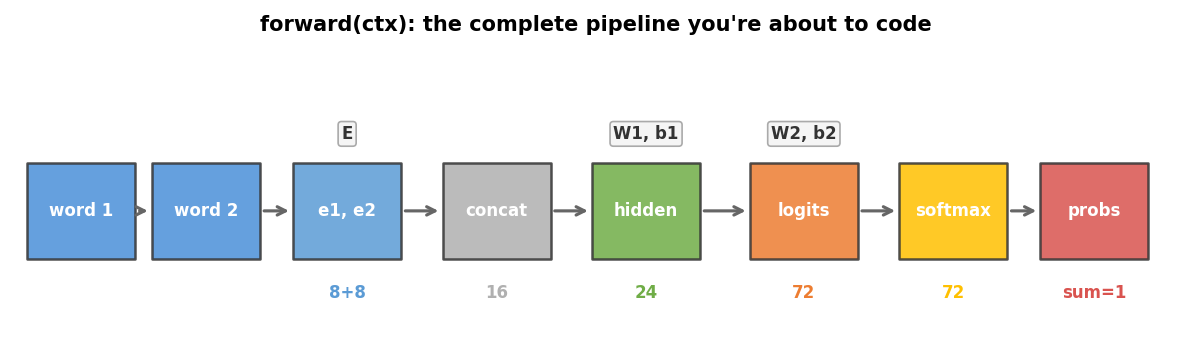


### ✏️ YOUR TURN #8 — write `forward(ctx)`

Write the function that chains everything together. `ctx` is a list of two word ids (the context).

**Everything you need is already defined** — this is the first time in the workshop where a single function pulls pieces from *every* earlier section:
- `E` — the embedding table from § 3
- `W1`, `b1` — the hidden layer weights from § 5
- `W2`, `b2` — the output layer weights you just created above
- `hidden()` — your function from § 5
- `softmax()` — your function from § 6

**Steps:**
1. Look up the two embeddings from `E`
2. Concatenate them into `x` using `np.concatenate`
3. Call your `hidden()` function
4. Compute `logits = W2 @ h + b2`
5. Return `softmax(logits)`


In [ ]:
def forward(ctx):
    """Run the full forward pass. ctx is a list of 2 word ids."""

    # 1. Look up the two embeddings from E
    #    E[ctx[0]] fetches the first word's vector (8 numbers)
    e1 = E[ctx[0]]                    # ✅ done
    e2 = ___                           # <-- same idea for the second word

    # 2. Concatenate them into one vector of length 16
    x = np.concatenate([e1, e2])       # ✅ done

    # 3. Run through the hidden layer (your function from §5)
    h = hidden(x, W1, b1)              # ✅ done

    # 4. Output scores: one per vocabulary word
    #    Same pattern as the hidden layer but WITHOUT tanh
    logits = ___                       # <-- W2 @ h + b2

    # 5. Turn logits into probabilities (your function from §6)
    return softmax(logits)              # ✅ done


In [ ]:
# ✅ Check
try:
    test_ctx = [word_to_idx["the"], word_to_idx["cat"]]
    probs = forward(test_ctx)
    assert probs.shape == (VOCAB_SIZE,), "output should have one entry per vocab word"
    assert np.isclose(probs.sum(), 1.0), "probabilities should sum to 1"
    assert np.all(probs >= 0), "probabilities should be non-negative"
    print("✅ forward() returns a valid probability distribution.")
    print(f"  Top-3 predictions after 'the cat' (untrained):")
    top = np.argsort(probs)[::-1][:3]
    for i in top:
        print(f"    {idx_to_word[i]:12s}  {probs[i]:.3f}")
except (AssertionError, TypeError, AttributeError):
    print("❌ Not quite. Walk through the 5 steps and compare to the skeleton.")


In [ ]:
# 💡 REFERENCE SOLUTION — uncomment and run only if you are stuck.
# (Full solutions: mini_llm_workshop_solutions.ipynb)
#
# def forward(ctx):
#     """Run the full forward pass. ctx is a list of 2 word ids."""
#     e1 = E[ctx[0]]
#     e2 = E[ctx[1]]
#     x = np.concatenate([e1, e2])
#     h = hidden(x, W1, b1)
#     logits = W2 @ h + b2
#     return softmax(logits)


### ▶️ Demo: what does the untrained model predict after `the cat`?

**What this cell does.** Runs the forward pass on the context
`['the', 'cat']` and draws a bar chart showing the probability the
model assigns to every word in the vocabulary for "the next word".

**Why we're running it.** To see the starting state of an untrained
model. Nothing has been learned yet, so its "predictions" are
essentially random.

**Watch for:**
- A roughly flat bar chart. Every word gets about `1 / 72 ≈ 0.014`
  probability. Tiny differences between bars are just due to random
  weight initialisation.
- The "most likely next word" printout will be some arbitrary word —
  almost never the right answer.
- **Take a mental snapshot.** After training in § 10, we'll run the
  same cell again and the bar chart will look dramatically different.


In [ ]:
# Bar chart of the untrained model's predictions after 'the cat'.
# With random weights, expect this to look roughly flat — the model
# has no opinions yet.
ctx = [word_to_idx["the"], word_to_idx["cat"]]
probs = forward(ctx)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(vocab, probs)
ax.set_ylabel("probability")
ax.set_title("After 'the cat', the UNTRAINED model predicts:")
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

print(f"Most likely next word: {idx_to_word[int(np.argmax(probs))]!r}")
print(f"Average probability  : {probs.mean():.3f}   (uniform would be {1/VOCAB_SIZE:.3f})")


---
## § 8 — Loss: how wrong are we?

### 📘 In plain English

We need a single number that tells us how badly the model is doing.
We call this number the **loss**.

The rule is simple: **how surprised was the model by the correct
answer?**

- If the model gave 0.99 probability to the right word → not very
  surprised → loss is tiny.
- If the model gave 0.001 probability to the right word → very
  surprised → loss is huge.

### The maths, with real numbers

The formula is `loss = -log(probability the model gave to the right word)`.

Why the `log`? Because log does something really useful here: it turns
probabilities near 1 into numbers near 0, and probabilities near 0 into
huge numbers. Look:

| Probability the model gave | `-log(p)` |
|----------------------------|-----------|
| 0.99                       | 0.01      |
| 0.90                       | 0.11      |
| 0.50                       | 0.69      |
| 0.10                       | 2.30      |
| 0.01                       | 4.61      |
| 0.001                      | 6.91      |

Confident-and-right barely costs anything. Confident-and-wrong costs a
lot. That is exactly the behaviour we want: the loss number punishes
bad predictions much harder than it rewards good ones.

### Starting point for our model

When the model is totally unsure and gives every word the same
probability (`1 / VOCAB_SIZE`), the loss works out to `log(VOCAB_SIZE)`.
Our vocabulary has 72 words, so we expect the untrained model's loss to
be around `log(72) ≈ 4.28`. That's our starting point. Training will
drag it down — not all the way to zero, because the branching prompts
we added introduce some irreducible uncertainty, but down to around
0.4–0.5.

This formula is called **cross-entropy loss** — that's just the formal
name. Don't get hung up on it. It's just "how surprised was the model".


### ✏️ YOUR TURN #9 — write `cross_entropy(p, target_id)`

Given a probability distribution `p` and the correct word id `target_id`, return the loss.

It's literally one line: `-log(p[target_id])`.

(We add a tiny `1e-12` inside the log to avoid `log(0)`.)


In [ ]:
def cross_entropy(p, target_id):
    """How surprised was the model by the correct answer?"""
    # The formula: -log( probability of the correct word )
    #   p[target_id]  → probability the model gave to the right word
    #   + 1e-12       → tiny safety margin to avoid log(0)
    #   np.log(...)   → natural logarithm
    #   negative      → because log of a number < 1 is negative
    return -np.log( ___ )  # <-- p[target_id] + 1e-12


In [ ]:
# ✅ Check
try:
    # Confident and right -> tiny loss
    p_right = np.zeros(VOCAB_SIZE); p_right[0] = 1.0
    assert cross_entropy(p_right, 0) < 0.01
    # Uniform -> loss around log(VOCAB_SIZE)
    p_uniform = np.full(VOCAB_SIZE, 1.0 / VOCAB_SIZE)
    assert abs(cross_entropy(p_uniform, 0) - np.log(VOCAB_SIZE)) < 0.01
    # Confident and wrong -> huge loss
    p_wrong = np.zeros(VOCAB_SIZE); p_wrong[1] = 1.0
    assert cross_entropy(p_wrong, 0) > 10
    print("✅ cross_entropy works: confident+right → small, wrong → huge.")
except (AssertionError, TypeError):
    print("❌ Not quite. Did you use -np.log(p[target_id] + 1e-12)?")


In [ ]:
# 💡 REFERENCE SOLUTION — uncomment and run only if you are stuck.
# (Full solutions: mini_llm_workshop_solutions.ipynb)
#
# def cross_entropy(p, target_id):
#     """How surprised was the model by the correct answer?"""
#     return -np.log(p[target_id] + 1e-12)


### ▶️ Demo: build the training data

**What this cell does.** For every sentence in `CORPUS` (the 17
sentences from § 1), it slides a window of 3 words across: the first
two become the *context*, the third becomes the *target* (what the
model should predict). Every window becomes one training example.

It uses `encode()` (from your § 1 exercise) to turn each sentence
into token ids, then pads with `START_ID` at the front and appends
`END_ID` at the end. `CONTEXT_SIZE = 2` (from § 5) decides how wide
the sliding window is.

**Why we're running it.** Training needs examples of the form "given
these two words, the next word should be this". This cell converts
our 17 sentences into ~114 such examples.

**Watch for:**
- `Total training examples: 114` (or similar). Small, but enough for
  our tiny model.
- The first few pairs printed: they should look like
  `['<START>', '<START>'] -> 'hello'`, `['<START>', 'hello'] -> 'hi'`,
  `['hello', 'hi'] -> 'there'`, etc.
- The `<START>` padding at the beginning is what lets us predict the
  first word of a sentence without a "real" context.


In [ ]:
# Build training pairs: slide a window of 3 words (2 context + 1 target)
# across every sentence in the corpus.
def make_pairs(sentence):
    ids = encode(sentence)
    padded = [START_ID] * CONTEXT_SIZE + ids + [END_ID]
    pairs = []
    for i in range(len(padded) - CONTEXT_SIZE):
        ctx = padded[i : i + CONTEXT_SIZE]
        tgt = padded[i + CONTEXT_SIZE]
        pairs.append((ctx, tgt))
    return pairs

train_pairs = []
for s in CORPUS:
    train_pairs.extend(make_pairs(s))

print(f"Total training examples: {len(train_pairs)}")
print()
print("First 6 pairs:")
for ctx, tgt in train_pairs[:6]:
    print(f"  {[idx_to_word[i] for i in ctx]}  ->  {idx_to_word[tgt]}")


### ▶️ Demo: measure the untrained model's loss

**What this cell does.** Runs the forward pass on every training
example, computes the cross-entropy loss for each one, and averages.
This gives us a single number that summarises "how bad is the model
right now".

**Why we're running it.** To establish a baseline. After training,
we'll want to see this number come way down.

**Watch for:**
- The untrained loss should be very close to `log(72) ≈ 4.28`. That's
  the "I have no idea what comes next" baseline — exactly what we
  expect from random weights.
- Remember this number. We're about to train the model and drop this
  loss to around 0.45.


In [ ]:
# Average loss of the untrained model across the whole training set.
total_loss = 0.0
for ctx, tgt in train_pairs:
    p = forward(ctx)
    total_loss += cross_entropy(p, tgt)
avg_loss = total_loss / len(train_pairs)

print(f"Untrained loss: {avg_loss:.4f}")
print(f"Uniform baseline log(V): {np.log(VOCAB_SIZE):.4f}")
print("(They should be very close — the model hasn't learned anything yet.)")


---
## § 9 — Hand-tune the weights ⏭️ *optional*

### 📘 In plain English

Before we let the computer train the model, let's see what "training"
actually is by **doing it ourselves**, by hand, for a single prediction.

We're going to pick a context, decide what word we want the model to
say, and manually set some weights to force that answer. Nothing fancy —
just assigning numbers to an array.

Why? Because then, when the computer does the same thing thousands of
times per second and calls it "gradient descent", you'll know it's not
magic — it's the same trick.

### The trick, step by step

Remember from § 4 that a row of `W2` dotted with `h` produces that
word's score. So if we want the model to predict `"is"` after
`"the cat"`, we need the score for `"is"` to be the biggest.

And remember from § 4 that a dot product of two vectors is big when the
vectors **point in the same direction**. So if we set the row of `W2`
for `"is"` to be *aligned* with `h` (the hidden state for our context),
the dot product will be big, the logit will be big, and softmax will
give `"is"` a big probability.

Concretely, if we set `W2[is_id] = h * 50`, then the logit for `"is"`
becomes `h • (h * 50) = 50 × (h • h) = 50 × ‖h‖²`, which is much
bigger than what the random weights give for any other row. That's the
whole trick — it's just a dot product intuition.


### ▶️ Demo: check the baseline probability

**What this cell does.** Picks a context (`['the', 'cat']`), picks
the word we *want* the model to predict (`'is'`), and prints the
current probability the untrained model gives to that word.

**Watch for:**
- The probability of `'is'` should be around `0.014` — very close to
  the uniform baseline of `1/72 ≈ 0.0139`. The model has no
  preference yet and is basically guessing. Our job in the exercise
  below is to change that with one line of code.


In [ ]:
# Our target: we want the model to predict 'is' after seeing 'the cat'.
ctx = [word_to_idx["the"], word_to_idx["cat"]]
target_word = "is"
target_id = word_to_idx[target_word]

# Look at the current prediction.
probs_before = forward(ctx)
print(f"Before tuning: P('{target_word}' | 'the cat') = {probs_before[target_id]:.4f}")
print(f"              (uniform baseline = {1/VOCAB_SIZE:.4f})")


### ▶️ Demo: compute the hidden state `h` for this context

**What this cell does.** Manually runs the first half of the forward
pass — looks up the two embeddings, glues them together, and runs
them through the hidden layer — saving the result as `h`. We need
`h` for the hand-tune trick in the exercise below.

**Watch for:**
- `h` is a vector of 24 numbers (the `HIDDEN_DIM`).
- The numbers are small (roughly in the range −0.3 to +0.3). They're
  whatever the untrained weights produce for this specific context.
- Its shape is `(24,)`. This is the vector we'll use in the exercise
  below to "align" a row of `W2` with.


In [ ]:
# Compute the hidden state h for this context. That's the vector that
# gets multiplied with each row of W2 to produce the scores.
e1 = E[ctx[0]]
e2 = E[ctx[1]]
x  = np.concatenate([e1, e2])
h  = hidden(x, W1, b1)

print("h for ('the', 'cat'):", np.round(h, 3))
print("shape:", h.shape)


### ✏️ YOUR TURN #10 — manually set `W2[target_id]` to favour 'is'

The score the model gives to a word is the dot product of `h` with the corresponding row of `W2`. To make 'is' the winner, we point the row for 'is' in the same direction as `h`, but make it 50 times longer. That makes the dot product big and positive, which means a big score, which means a big probability.

We're literally just assigning one row of `W2` to a new value. Then we re-run `forward(ctx)` and see the prediction flip.


In [ ]:
# Set the row of W2 for our target word to point in the same
# direction as h, but 50x bigger. This makes the dot product huge.
#
# The line you need:  W2[target_id] = h * 50
#
___  # <-- assign W2[target_id]

# Now re-run the forward pass and look at the new prediction.
probs_after = forward(ctx)
print(f"After tuning:  P('{target_word}' | 'the cat') = {probs_after[target_id]:.4f}")


In [ ]:
# ✅ Check — is 'is' now the top prediction and did probability jump?
try:
    assert int(np.argmax(probs_after)) == target_id, (
        "'is' should now be the top prediction after tuning"
    )
    assert probs_after[target_id] > probs_before[target_id] * 5, (
        "the probability of 'is' should have jumped by at least 5x"
    )
    top_word = idx_to_word[int(np.argmax(probs_after))]
    ratio = probs_after[target_id] / probs_before[target_id]
    print(f"✅ Probability of 'is' went from "
          f"{probs_before[target_id]:.3f} → {probs_after[target_id]:.3f} "
          f"({ratio:.1f}x higher)")
    print(f"   Top prediction is now: {top_word!r}")
    print("   Congratulations — you just trained one weight by hand.")
except AssertionError as e:
    print("❌ Not quite:", e)
except NameError:
    print("❌ Did you run the W2 assignment and re-run forward()?")


In [ ]:
# 💡 REFERENCE SOLUTION — uncomment and run only if you are stuck.
# (Full solutions: mini_llm_workshop_solutions.ipynb)
#
# W2[target_id] = h * 50
#
# probs_after = forward(ctx)
# print(f"After tuning:  P('{target_word}' | 'the cat') = {probs_after[target_id]:.4f}")


**Takeaway.** "Training" is *exactly* this — nudging numbers in
`E`, `W1`, `W2`, `b1`, `b2` so that the right word gets higher
probability for each context. Automatic training (next section) just
does it for every example in the training data, thousands of times per
second, using calculus to decide which direction each number should go.


---
## § 10 — Training: let the computer do what you just did

### 📘 In plain English

You already trained one weight by hand in the last section. Training
the whole model is the same idea, just automated and repeated thousands
of times.

The automated version is called **gradient descent**. Here's the
intuition:

> Imagine you're standing on a hillside, blindfolded, and you want to
> reach the bottom of the valley. You can't see anything, but you can
> feel which direction is downhill right where you're standing. So
> you take a small step that way. Then you feel again. Another step.
> Repeat until you can't go any lower.

That's gradient descent. The "hillside" is the loss: high loss means
you're high on the hill, low loss means you've found the valley. The
"downhill direction" for every weight is called the **gradient**, and
the maths trick for computing all the gradients efficiently is called
**backpropagation** (or "backprop" for short).

### You don't need to understand backpropagation

We provide a function called `train_step()` that takes one training pair,
runs the forward pass, works out the downhill direction for every
weight using the chain rule from calculus, and nudges each weight a
tiny bit in that direction. You can open the cell below and read it if
you're curious, but **you do not need to understand the gradients to
use this function**. We will treat it as a black box: "this function
makes the loss go down a little bit each time you call it".


### 📦 Pre-built helper: `train_step`

**What this cell does.** Defines a helper function that takes one
`(context, target)` training pair and performs **one step of gradient
descent**. It runs the forward pass, works out which direction every
weight needs to move to reduce the loss, and nudges all five parameter
tables (`E`, `W1`, `b1`, `W2`, `b2`) by a small amount.

**Why we're giving it to you pre-built.** Computing gradients is just
the chain rule from calculus, applied mechanically to our specific
architecture. It is not conceptually hard, but writing it out is
fiddly and error-prone. If you want to read the code, feel free — but
you absolutely don't need to.

**What you need to remember:** calling `train_step(ctx, target)`
changes the weights slightly, in a direction that reduces loss on
*that* example. Call it many times on many examples and loss goes
down for the whole dataset.


In [ ]:
# 📦 PRE-BUILT HELPER — you do NOT need to understand this to continue.
# It does one gradient descent step for one (context, target) pair.
#
# It re-derives the gradients of cross-entropy + softmax + the hidden layer
# using the chain rule and nudges every weight a little bit downhill.
def train_step(ctx, target_id, lr=0.1):
    # Forward pass (same as forward() but we keep the intermediate values)
    e1 = E[ctx[0]]
    e2 = E[ctx[1]]
    x  = np.concatenate([e1, e2])
    z1 = W1 @ x + b1
    h  = np.tanh(z1)
    z2 = W2 @ h + b2
    p  = softmax(z2)

    # Gradients (the chain rule applied to our 5 parameters)
    dz2 = p.copy(); dz2[target_id] -= 1.0
    dW2 = np.outer(dz2, h)
    db2 = dz2
    dh  = W2.T @ dz2
    dz1 = dh * (1.0 - h * h)
    dW1 = np.outer(dz1, x)
    db1 = dz1
    dx  = W1.T @ dz1
    de1 = dx[:EMBED_DIM]
    de2 = dx[EMBED_DIM:]

    # SGD update (nudge every weight downhill by lr times its gradient).
    # We use slice assignment (name[:] -= ...) rather than bare -= so that
    # Python treats these as in-place modifications of the module-level
    # arrays instead of trying to rebind them as local variables.
    E[ctx[0]] -= lr * de1
    E[ctx[1]] -= lr * de2
    W1[:]     -= lr * dW1
    b1[:]     -= lr * db1
    W2[:]     -= lr * dW2
    b2[:]     -= lr * db2

    return -np.log(p[target_id] + 1e-12)


### ▶️ Demo: reset all the weights

**What this cell does.** Overwrites `E`, `W1`, `b1`, `W2`, and `b2`
with fresh random values (well, fresh zeros for the biases). In other
words: throws away anything the previous sections did to the weights
(including our hand-tuning in § 9) and starts from a clean slate.

**Why we're running it.** Because the hand-tune exercise in § 9
deliberately messed with one row of `W2`. If we trained from that
corrupted starting point, we'd get weird results. Resetting guarantees
training starts from a known clean state.

**Watch for:** The single confirmation line. The model is now back to
"knows nothing" and ready to be trained.


In [ ]:
# Reset all the weights to random, fresh values before training.
# (We messed with W2 in the hand-tune section.)
E[:]  = rng.standard_normal((VOCAB_SIZE, EMBED_DIM)) * 0.1
W1[:] = rng.standard_normal((HIDDEN_DIM, INPUT_DIM)) * 0.1
b1[:] = 0.0
W2[:] = rng.standard_normal((VOCAB_SIZE, HIDDEN_DIM)) * 0.1
b2[:] = 0.0

print("Weights reset — ready to train.")


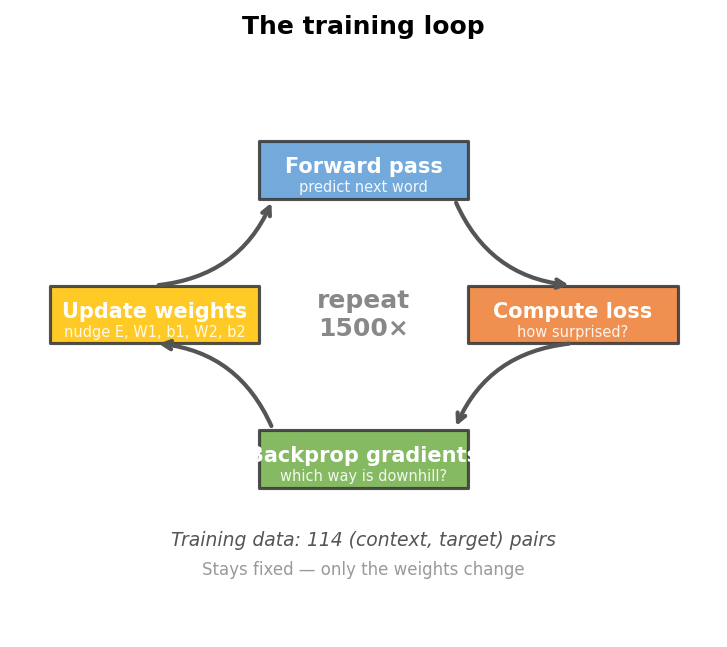


### ✏️ YOUR TURN #11 — write the training loop

Write the nested loop that trains the model.

**What you're combining here** (everything you need is already defined):
- `train_pairs` — the list of (context, target) pairs built in § 8.
- `train_step(ctx, target, lr=LR)` — the pre-built helper from earlier in this section. Returns the loss for that one pair.
- `EPOCHS = 1500` and `LR = 0.1` — given in the skeleton.

**Steps:**
1. Outer loop: repeat for `EPOCHS` epochs
2. Inner loop: for each `(ctx, target)` pair in `train_pairs`, call `train_step` and add the returned loss to a running total
3. After each epoch, record the average loss in `losses`


In [ ]:
EPOCHS = 1500
LR = 0.1
losses = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0

    # Inner loop: go through every training pair and nudge the weights.
    # train_step(ctx, target, lr=LR) returns the loss for that pair.
    for ctx, target in train_pairs:
        epoch_loss += ___  # <-- call train_step and add its return value
                           #     train_step(ctx, target, lr=LR)

    losses.append(epoch_loss / len(train_pairs))  # ✅ done

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss  : {losses[-1]:.4f}")


In [ ]:
# ✅ Check: did the loss drop?
try:
    assert len(losses) == 1500, "should have one loss per epoch"
    assert losses[-1] < 0.6, f"final loss should be < 0.6, got {losses[-1]:.4f}"
    print(f"✅ Training converged. Loss dropped from "
          f"{losses[0]:.3f} to {losses[-1]:.3f}")
except AssertionError as e:
    print("❌", e)
except (NameError, TypeError):
    print("❌ Did you define and fill in the training loop?")


In [ ]:
# 💡 REFERENCE SOLUTION — uncomment and run only if you are stuck.
# (Full solutions: mini_llm_workshop_solutions.ipynb)
#
# EPOCHS = 1500
# LR = 0.1
# losses = []
#
# for epoch in range(EPOCHS):
#     epoch_loss = 0.0
#     for ctx, target in train_pairs:
#         epoch_loss += train_step(ctx, target, lr=LR)
#     losses.append(epoch_loss / len(train_pairs))
#
# print(f"Initial loss: {losses[0]:.4f}")
# print(f"Final loss  : {losses[-1]:.4f}")


### ▶️ Demo: plot the loss curve

**What this cell does.** Plots the list of per-epoch losses you
collected in the training loop above. X-axis is the epoch number,
Y-axis is the average loss on the training set at the end of that
epoch.

**Why we're running it.** Because this picture — the loss curve — is
the single most important diagnostic in all of machine learning. If
it goes down smoothly, training is healthy. If it's bouncing around
or going up, something is broken.

**Watch for:**
- Starts near `4.28` (the "knows nothing" baseline) on the left.
- Drops rapidly in the first few hundred epochs.
- Flattens out near `0.45` by the end. It doesn't reach zero because
  our corpus has 'branching' prompts (`hi`, `goodbye`, `hey`,
  `can you`) where more than one next word is valid — the model
  cannot be simultaneously confident about all of them.
- Smooth and monotonically decreasing — no sudden jumps or plateaus.
  That's what healthy training looks like.


In [ ]:
# Plot the loss curve.
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("average loss")
plt.title("Training loss — the model getting less surprised")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### ▶️ Demo: the TRAINED embedding heatmap

**What this cell does.** Re-renders the `E` heatmap we saw in § 3,
but now with the *trained* weights. Compare this directly against
the random noise version you saw earlier.

**Why we're running it.** This is the first visual proof that
training did something meaningful. The random splotches should now
have structure — similar words should have similar coloured rows.

**Watch for:**
- Rows are no longer random scatter. You should see *horizontal
  patterns* — some rows are mostly red, others mostly blue.
- Words that share contexts (e.g. `python` / `code` / `programming`)
  should have visually similar row patterns.
- The overall colour range is wider than before (darker reds and
  blues) because training has pushed the numbers further from zero.


In [ ]:
# Now look at the embedding table again. Compare to the random one from § 3.
fig, ax = plt.subplots(figsize=(6, max(3, VOCAB_SIZE * 0.2)))
im = ax.imshow(E, cmap="RdBu", aspect="auto")
ax.set_yticks(range(VOCAB_SIZE))
ax.set_yticklabels(vocab, fontsize=8)
ax.set_xticks(range(EMBED_DIM))
ax.set_xlabel("embedding dimension")
ax.set_title("Embedding table E (AFTER training)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


### ▶️ Demo: the trained embeddings projected into 2D

**What this cell does.** Takes our 8-dimensional word vectors and
projects them down to 2 dimensions using a technique called **PCA**
(Principal Component Analysis) so we can scatter-plot them on a flat
page. PCA is just "find the two directions that capture the most
variance in the data and throw the rest away". You don't need to
understand PCA — it's just a way to compress 8D to 2D for plotting.

**Why we're running it.** This is the workshop's biggest payoff
moment. If training worked, words with similar meanings should end
up near each other on the scatter plot. It's the most visceral way
to see that embeddings encode *meaning*.

**Watch for:**
- Words that appear in similar contexts cluster together:
  - `python`, `code`, `programming`, `computer` should be near each
    other (they all show up in the programming sentences).
  - `sun`, `moon`, `sky`, `nights` should be close (celestial /
    night-sky group).
  - `cat`, `dog`, `bed`, `tree` (the animal/nature words) should
    form their own group.
  - The branching greeting words `hi`, `goodbye`, `hey`, `hello`
    often end up in their own neighbourhood.
  - Function words like `the`, `is`, `a` usually sit somewhere in
    the middle.
- The model learned these relationships from just 17 sentences with
  no supervision about word meanings — purely from "which words
  appear in similar contexts".


In [ ]:
# Project the 8-dimensional embeddings down to 2D with PCA so we can
# plot them. Words that appear in similar contexts should cluster.
centered = E - E.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(centered, full_matrices=False)
coords_2d = centered @ Vt[:2].T

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(coords_2d[:, 0], coords_2d[:, 1], s=40)
for i, w in enumerate(vocab):
    ax.annotate(w, (coords_2d[i, 0], coords_2d[i, 1]),
                xytext=(5, 5), textcoords="offset points", fontsize=9)
ax.set_title("Trained embeddings in 2D (PCA)\n"
             "Look for clusters — python/code, sun/moon, cat/dog, etc.")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## § 11 — Generation: making the model talk

### 📘 In plain English

Generation is just a `for` loop around `forward()`:

1. Take the prompt and encode it into token ids.
2. Look at the last 2 tokens (that's the context the model sees).
3. Call `forward()` to get the probability of every possible next word.
4. Pick the most likely one.
5. Append it to the output, slide the context window, and loop.
6. Stop when the model picks `<END>`.

That's it. Generation is not a separate concept from the model — it's
the same `forward()` function you already wrote, run in a loop.

### A couple of jargon words you'll see

- **`np.argmax(p)`** — "argmax" means "the *index* of the biggest number
  in the array". If `p = [0.1, 0.7, 0.2]`, then `np.argmax(p) == 1`
  because the biggest value (`0.7`) is at position 1. We use argmax to
  find which word has the highest probability.
- **Greedy decoding** — at every step, always pick the single most
  likely next word (the argmax). It's called "greedy" because it takes
  whatever looks best right now without considering the future. It's
  fast, deterministic, and great for testing. The alternative is
  *sampling* (roll a weighted die), which gives more variety.


### ✏️ YOUR TURN #12 — write `generate(prompt, max_tokens=20)`

The outer loop and the prompt encoding are given. Fill in the 4 TODOs inside the loop.

**Everything you need already exists** (quick reminder):
- `encode()` — from § 1, turns a string prompt into token ids.
- `decode()` — from § 1, turns token ids back into a string.
- `forward(ctx)` — from § 7, the whole trained model.
- `CONTEXT_SIZE = 2` — from § 5, the window size.
- `START_ID`, `END_ID` — from § 1, the special-token ids.

**Inside the loop:**
1. Take the last `CONTEXT_SIZE` tokens of `context` → `ctx`
2. Call `forward(ctx)` → `p`
3. Pick `np.argmax(p)` as the next id
4. If it's `END_ID`, break. Otherwise append it to both `output` and `context`


In [ ]:
def generate(prompt, max_tokens=20):
    """Greedy decoding: keep picking the most likely next word."""
    tokens  = encode(prompt)                       # ✅ done
    context = [START_ID] * CONTEXT_SIZE + tokens    # ✅ done
    output  = list(tokens)                          # ✅ done

    for _ in range(max_tokens):
        # 1. Slide the context window: take the LAST 2 tokens
        ctx = context[-CONTEXT_SIZE:]               # ✅ done

        # 2. Run the model to get probabilities
        p = ___                                     # <-- forward(ctx)

        # 3. Pick the most likely word (greedy = argmax)
        next_id = int(np.argmax(p))                 # ✅ done

        # 4. If we hit the END marker, stop generating
        if next_id == END_ID:
            break

        # 5. Otherwise, append this word and keep going
        output.append(next_id)                      # ✅ done
        context.append(next_id)                     # ✅ done

    return decode(output)


In [ ]:
# ✅ Check: does generate('hello') produce the expected sentence?
try:
    out = generate("hello")
    assert out == "hello hi there friend", f"got {out!r}"
    print("✅ generate('hello') =", repr(out))
except AssertionError as e:
    print("❌ Not quite:", e)
except Exception as e:
    print("❌ Your code raised", type(e).__name__, "-", e)


In [ ]:
# 💡 REFERENCE SOLUTION — uncomment and run only if you are stuck.
# (Full solutions: mini_llm_workshop_solutions.ipynb)
#
# def generate(prompt, max_tokens=20):
#     """Greedy decoding: keep picking the most likely next word."""
#     tokens  = encode(prompt)
#     context = [START_ID] * CONTEXT_SIZE + tokens
#     output  = list(tokens)
#
#     for _ in range(max_tokens):
#         ctx = context[-CONTEXT_SIZE:]
#         p = forward(ctx)
#         next_id = int(np.argmax(p))
#         if next_id == END_ID:
#             break
#         output.append(next_id)
#         context.append(next_id)
#
#     return decode(output)


### 🎉 Demo: run generation on every canonical prompt

**What this cell does.** Calls your `generate()` function on each of
the 8 prompts the model was trained to respond to, and prints the
result.

**Why we're running it.** This is the grand finale. If everything
from § 1 through § 11 worked, every single one of these prompts
should produce the complete training sentence it came from.

**Watch for:**
- Each prompt should produce its full training sentence. For example:
  - `'hello'` → `'hello hi there friend'`
  - `'what is the sun'` → `'what is the sun it lights up our sky'`
- All 8 should work. If any one produces garbage, either training
  didn't fully converge or there's a bug in `generate()`.
- **You wrote this.** Every single part. No library did the thinking
  for you. That's the workshop's payoff.


In [ ]:
# 🎉 Try all the canonical prompts.
PROMPTS = [
    "hello",
    "the cat is happy on the",
    "a dog barks at the",
    "what is the sun",
    "the moon shines down during",
    "i love writing python",
    "python makes programming",
    "code runs fast on",
]
for prompt in PROMPTS:
    print(f"  {prompt!r:40s} -> {generate(prompt)!r}")


---
## § 11.5 — The model learned a *distribution*, not a sentence

### 📘 In plain English

So far, every time you run `generate('hello')` you get exactly
`'hello hi there friend'`. Every time. Same input, same output. That
looks a lot like the model just *memorised* one sentence for each
prompt — which is not really what a language model is supposed to do.

But there are some prompts where the training data had **more than one
valid answer**. Remember the branching sentences we sneaked into the
corpus back in § 1?

```
hi nice to meet you
hi how are you today
hi welcome home friend
```

After seeing `'hi'`, the model was shown three different "correct"
next words during training. It can't be simultaneously certain about
all three, so it learns to assign each one roughly **one-third**
probability. That's a *distribution*, not a single answer.

Greedy decoding hides this from us. It always picks the single biggest
number, so it locks onto whichever of the three happened to win by a
hair. Let's look *underneath* greedy decoding and see the real
distribution the model learned.


### ▶️ Demo: greedy hides the variation

**What this cell does.** Runs `generate('hi')` five times in a row
under greedy decoding.

**Watch for:** The exact same output every time. That's because
greedy decoding is deterministic — same input → same `forward()` →
same `argmax` → same output. It doesn't show us anything about the
underlying distribution.


In [ ]:
# Greedy generation is deterministic.
for _ in range(5):
    print("   ", generate("hi"))


### ▶️ Demo: peek at the probability distribution

**What this cell does.** Runs `forward()` on the context
`(<START>, 'hi')` and prints the top 5 probabilities.

**Watch for:**
- Three words (`nice`, `how`, `welcome`) should each have probability
  around `0.33` — the model split its belief roughly evenly between
  the three training options.
- Every other word in the 72-word vocabulary should be close to zero.
- **This is proof the model genuinely learned a distribution.** It's
  not guessing randomly — it's assigning meaningful probability to
  exactly the right handful of words and near-zero to everything else.


In [ ]:
# Look at the probability distribution at the 'hi' branch point.
ctx = [START_ID] * (CONTEXT_SIZE - 1) + encode("hi")
ctx = ctx[-CONTEXT_SIZE:]
probs = forward(ctx)

top5 = np.argsort(probs)[::-1][:5]
print("Top 5 most likely words after 'hi':")
for i in top5:
    bar = "#" * int(probs[i] * 50)
    print(f"  {idx_to_word[i]:10s}  {probs[i]:.3f}  {bar}")


### ▶️ Demo: the distribution as a bar chart

**What this cell does.** Plots the full 72-word probability
distribution after `'hi'` as a bar chart.

**Watch for:**
- Three visibly tall bars (`nice`, `how`, `welcome`), each at
  roughly `1/3`.
- Everything else flat near zero.
- Compare this to the bar chart from § 7 on the *untrained* model
  after `'the cat'`, where all 72 bars looked the same. Training has
  sharpened the distribution — but only onto the words that actually
  made sense, not onto a single answer.


In [ ]:
# Bar chart of the distribution after 'hi'.
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(vocab, probs)
ax.set_ylabel("probability")
ax.set_title("After 'hi', the TRAINED model predicts a DISTRIBUTION:")
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.tight_layout()
plt.show()


### So how do we actually *use* that distribution?

We need a different decoding strategy: **sampling**. Instead of always
picking the single biggest probability, we roll a weighted die. If
`nice` has probability `0.33`, it gets chosen roughly 33% of the time.
If `how` has probability `0.33`, same thing. This way, running
generation multiple times actually produces *different* outputs —
because the randomness is baked into the decoding step.

### Temperature — the "creativity dial"

We also get a knob to control how *adventurous* the sampling is,
called **temperature** (`T`). Before applying softmax, we divide the
logits by `T`:

- **`T = 1.0`** — use the raw probabilities the model learned.
- **`T < 1.0`** (e.g. `0.2`) — sharpens the distribution. The top
  probability gets even more weight; less likely words get crushed.
  At very low temperature, sampling acts almost like greedy decoding.
- **`T > 1.0`** (e.g. `2.0`) — flattens the distribution. All words
  get more equal shots, so the model picks weirder words more often.
  Outputs become more creative and also more nonsensical.

This is the same "temperature" slider you might have seen in the
ChatGPT or Claude API. Now you know *exactly* what it does.


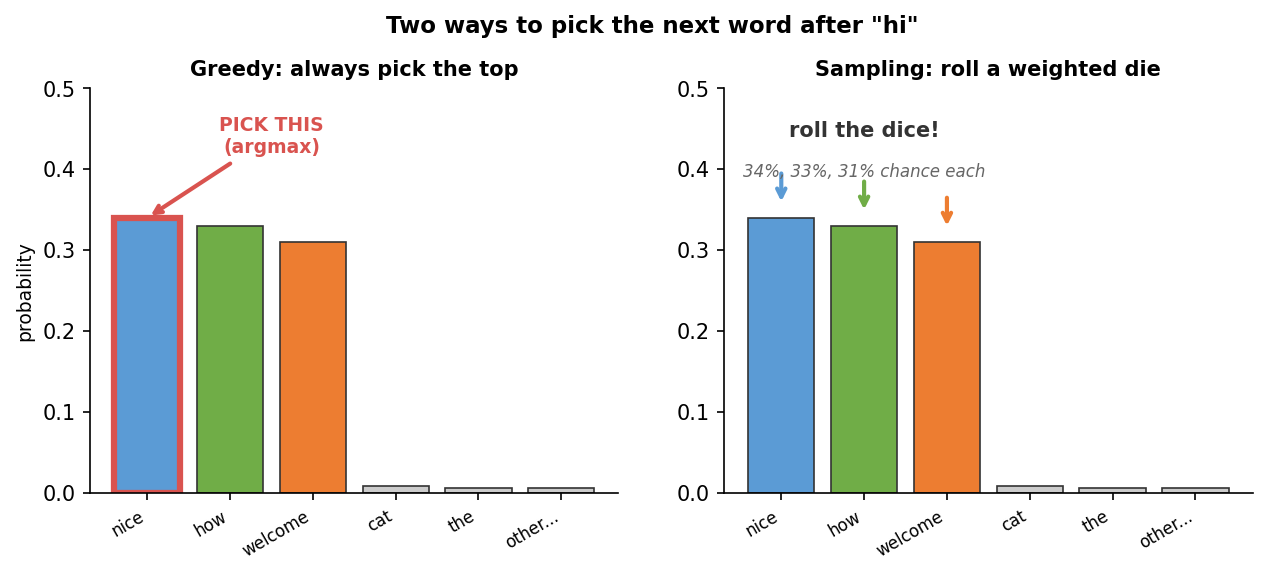


### ✏️ YOUR TURN #13 — write `sample(prompt, temperature=1.0)`

Write a new decoding function that samples from the distribution instead of always picking `argmax`. Most of the code is given — you just fill in the 3 TODOs in the loop.

**Inside the loop:**
1. Take the last `CONTEXT_SIZE` tokens of `context` → `ctx` (already done)
2. Call `forward(ctx)` → `p`
3. Apply temperature: if `temperature != 1.0`, divide the *log* of `p` by `temperature` and re-softmax (already done)
4. Use `rng.choice(VOCAB_SIZE, p=p)` to sample the next id (instead of `np.argmax(p)`)


In [ ]:
def sample(prompt, max_tokens=20, temperature=1.0):
    """Sampling decoder: pick words randomly, weighted by their probability."""
    tokens  = encode(prompt)
    context = [START_ID] * CONTEXT_SIZE + tokens
    output  = list(tokens)

    for _ in range(max_tokens):
        # 1. Slide the context window (same as generate)
        ctx = context[-CONTEXT_SIZE:]                # already done

        # 2. Get probabilities from the model
        p = ___                                      # <-- forward(ctx)

        # 3. Apply temperature (this part is done for you)
        if temperature != 1.0:
            logits = np.log(p + 1e-12) / temperature
            p = softmax(logits)
        # 4. SAMPLE instead of argmax — this is the key change!
        #    rng.choice(VOCAB_SIZE, p=p) rolls a weighted die
        next_id = int( ___ )                         # <-- rng.choice(VOCAB_SIZE, p=p)

        if next_id == END_ID:
            break
        output.append(next_id)
        context.append(next_id)

    return decode(output)


In [ ]:
# ✅ Check: does sample('hi') actually produce variety over many runs?
try:
    outputs = set()
    for _ in range(30):
        outputs.add(sample("hi"))
    assert len(outputs) >= 2, (
        f"expected at least 2 different outputs over 30 runs, got {len(outputs)}"
    )
    print(f"✅ sample('hi') produced {len(outputs)} different outputs over 30 runs:")
    for o in sorted(outputs):
        print(f"   • {o}")
except AssertionError as e:
    print("❌ Not quite:", e)
except Exception as e:
    print("❌ Your code raised", type(e).__name__, "-", e)


In [ ]:
# 💡 REFERENCE SOLUTION — uncomment and run only if you are stuck.
# (Full solutions: mini_llm_workshop_solutions.ipynb)
#
# def sample(prompt, max_tokens=20, temperature=1.0):
#     """Sampling decoder: pick words randomly, weighted by their probability."""
#     tokens  = encode(prompt)
#     context = [START_ID] * CONTEXT_SIZE + tokens
#     output  = list(tokens)
#
#     for _ in range(max_tokens):
#         ctx = context[-CONTEXT_SIZE:]
#         p = forward(ctx)
#
#         if temperature != 1.0:
#             logits = np.log(p + 1e-12) / temperature
#             p = softmax(logits)
#
#         next_id = int(rng.choice(VOCAB_SIZE, p=p))
#
#         if next_id == END_ID:
#             break
#         output.append(next_id)
#         context.append(next_id)
#
#     return decode(output)


### ▶️ Demo: run `sample('hi')` five times

**What this cell does.** Runs the `sample()` function you just wrote
five times on the same prompt.

**Watch for:** Different outputs across runs. Each run rolls the dice
at the `(hi, ?)` branch point and picks one of the three possible
continuations (`nice`, `how`, `welcome`), then continues down that
path to the end of that sentence.


In [ ]:
# Sampling produces real variation on branch-point prompts.
print("sample('hi') five times:")
for _ in range(5):
    print("   ", sample("hi"))

print()
print("sample('goodbye') five times:")
for _ in range(5):
    print("   ", sample("goodbye"))


### ▶️ Demo: temperature — the creativity dial

**What this cell does.** Runs `sample('hi')` three times at each of
three different temperatures: very low (`0.2`), default (`1.0`), and
very high (`2.0`).

**Watch for:**
- **`T = 0.2`** — outputs look almost the same every run. Low
  temperature sharpens the distribution, making the single most
  likely path dominant. Basically greedy.
- **`T = 1.0`** — natural variation. You should see all three of the
  `hi` continuations show up over a few runs.
- **`T = 2.0`** — chaos. The flattened distribution lets unlikely
  words slip through, so you'll see bizarre or grammatically broken
  outputs. This is the classic "model is too hot" behaviour.


In [ ]:
# Temperature demo: low = predictable, high = creative.
for T in [0.2, 1.0, 2.0]:
    print(f"temperature = {T}")
    for _ in range(3):
        print("   ", sample("hi", temperature=T))
    print()


### Takeaway

This is the missing half of what makes a language model feel like a
language model. Our model isn't a memoriser — it learned a
*probability distribution* over the next word at every point, and
different decoding strategies surface that distribution in different
ways:

- **Greedy** — deterministic, reproducible, boring.
- **Sampling at T=1.0** — faithful to what the model actually
  learned. Natural variety where variety exists in the training data.
- **Low temperature** — almost-greedy, safe outputs.
- **High temperature** — creative, weird, sometimes nonsensical.

This is literally why ChatGPT gives you different answers when you
ask the same question twice, and why the API has a `temperature`
parameter. Same idea, same maths, just much bigger.


---
## § 12 — Playtime: make it your own ⏭️ *optional*

### 📘 In plain English

The model you just built is completely yours to mess with. A few
things to try.

### 🎯 Add your own phrase and re-train

1. Scroll up to § 1 and add a sentence to `CORPUS`, e.g.
   `"the workshop was fun and educational"`.
2. Re-run the vocabulary cell (it rebuilds `word_to_idx`).
3. Re-run the training cell.
4. Test with `generate("the workshop was fun and")`.

### 🎲 Add your own *branch point* and see sampling find it

This is the really fun one. Add multiple sentences that share a prefix
with each other — just like the `hi` / `goodbye` / `hey` / `can you`
branches already in the corpus. For example:

```
how about some coffee
how about a walk outside
how about we start now
```

Re-run the vocab and training cells, then try `sample("how about")`
several times. The model should produce all three continuations over
multiple runs. You just added adaptive behaviour to your own model.

**Gotcha:** your new phrase cannot share a bigram with an *existing*
canonical phrase that has a different next word, or greedy generation
on one of the canonical prompts will break. Branches are fine inside
your own new phrases — that's the whole point — just don't collide
with the existing 8 canonical paths (the first 8 sentences in
`CORPUS`, the ones *without* shared prefixes).

### 🔬 Experiment prompts

- Set `EPOCHS = 100` instead of 1500. How does the loss curve look?
  What happens to the distribution at the `hi` branch point?
- Set `LR = 1.0` (10× larger). What happens?
- Set `sample("hi", temperature=0.01)` — does it ever output anything
  except the top option? Why not?
- Set `sample("hi", temperature=5.0)` — how many different outputs
  can you get over 10 runs?
- Can you make the model say your name if you add the right phrase?


---
## § 13 — How this connects to real LLMs

Congratulations — you have built, trained, and run a language model
from scratch.

| You just wrote                | A real LLM has              |
|-------------------------------|-----------------------------|
| 72-word vocabulary            | ~100,000 subword tokens     |
| Embedding dim 8               | Embedding dim 4,000+        |
| Context of 2 words            | Context of 100,000+ tokens  |
| 1 hidden layer of size 24     | 100+ transformer blocks     |
| ~2,800 parameters             | Billions to trillions       |
| 17 sentences of training data | Trillions of tokens         |
| `concat last 2 embeddings`    | `attention over all tokens` |

**The one big thing we are missing: attention.** Instead of always
looking at the last 2 words, a transformer can look at *every* previous
word and decide, on the fly, which ones matter for the next prediction.
That is the heart of the "transformer" architecture.

But the basic recipe — embed → mix → squash → produce probabilities
→ train with gradient descent → generate one token at a time — is the
same. Every single line you wrote today has a cousin inside ChatGPT.

**Where to go next:**
- Andrej Karpathy's "Neural Networks: Zero to Hero" YouTube series.
- The original *Attention Is All You Need* paper (transformers).
- Re-implement this same model in PyTorch and replace `train_step` with
  `loss.backward(); optimizer.step()`.

Thanks for building with us. 🎉
